In [2]:
import numpy as np
import pysheaf as ps
import scipy
import scipy.linalg
import matplotlib.pyplot as plt
import math

class NetlistSheaf(ps.Sheaf):
    def __init__(self, parts, nets, **kwargs):
        '''
Construct a netlist sheaf using a dictionary of `parts` and `nets`.  
Additional optional arguments accepted as `**kwargs`, so that these can be used as parameters as the sheaf is being built.  

> [!CAUTION]
> This function uses `eval()` to unpack and build Python expressions from strings.  You have been warned; sanitize your input!

Each part is named, and has fields:
* `data_dimension`, 
* `bounds` (optional), 
* `ports`.

The `ports` field is a dictionary naming each port, and associating a string that defines a function for the corresponding restriction map.  

Example:
```
{ "AND2" : { "data_dimension" : 2,
	     "bounds" : "[(0,1)]*2",
	     "ports" : { "IN1" : "lambda x: x[0]",
		       "IN2" : "lambda x: x[1]",
		       "OUT" : "lambda x: x[0]*x[1]" }},
...}
```

Each net is named, and has fields:
* `data_dimension`,
* `bounds` (optional),
* `value` (optional; NB: parsed with `eval()`),
* `optimize` (optional; anything not integer `0` is `True`; default = `True`),
* `constraint` (optional; 'equality' -> `pysheaf.CellConstraintType.EQUALITY`, 'inequality' -> `pysheaf.CellConstraintType.INEQUALITY`, anything else is `pysheaf.CellConstraintType.NONE`)
* `connections`.
Subsequently, `connections` is a list of dictionaries, each one has a `part` and `port` field, which index into the `parts` dictionary above.

```
Example
{
    "A": {
	"data_dimension" : 1,
	"bounds" : "[(0,1)]",
	"connections" : [
	       { "part" : "AND2",
		 "port" : "IN1"}
	   ]
    },
...}
```

> [!TIP]
> The default behavior is that all parts are optimization cells, and that no nets are optimization cells.
        '''
        
        ps.Sheaf.__init__(self)

        self.mNumpyNormType=2

        # First, build the parts (lower level of poset)
        for k,v in parts.items():
            if isinstance(v['data_dimension'],int):
                ddim = v['data_dimension']
            else:
                ddim = eval(v['data_dimension'])
                
            self.AddCell(k,
                         ps.Cell('part',
                                 dataDimension = ddim))
                
            self.GetCell(k).SetDataAssignment(ps.Assignment('part',np.zeros((ddim,))))
            self.GetCell(k).mOptimizationCell = True

        # Next, build the nets (upper level of poset)
        for k,v in nets.items():
            if isinstance(v['data_dimension'],int):
                ddim = v['data_dimension']
            else:
                ddim = eval(v['data_dimension'])

            self.AddCell(k,
                         ps.Cell('net',
                                 dataDimension = ddim))
            
            try:
                self.GetCell(k).SetDataAssignment(ps.Assignment('net',eval(v['value'])))
            except KeyError:
                self.GetCell(k).SetDataAssignment(ps.Assignment('net',np.zeros((ddim,))))

            try:
                self.GetCell(k).mOptimizationCell = (v['optimize']!=0)
            except KeyError:
                pass

            try:
                if v['constraint'] == 'inequality':
                    self.GetCell(k).mConstraintType = ps.CellConstraintType.INEQUALITY
                elif v['constraint'] == 'equality':
                    self.GetCell(k).mConstraintType = ps.CellConstraintType.EQUALITY
            except KeyError:
                pass

            # Connect each part in this net
            for vp in v['connections']:
                part=vp['part']
                port=vp['port']
                self.AddCoface(part,k,
                               ps.Coface('part','net',
                                         eval(parts[part]['ports'][port])))
        return

In [3]:
import csv
import json
import sys
import numpy as np
import scipy.linalg
import networkx as nx
import pysheaf as ps
import matplotlib.pyplot as plt
sys.path.append('/Users/trixiesouthwood/Downloads/research/netlist-sheaf')
import netlist_sheaf
import numpy.random
import numpy.polynomial
from collections import defaultdict

In [4]:
### Example based upon Figure 4 in
# Thorson et al., "Dynamic structural equation models synthesize ecosystem dynamics constrained by ecological mechanisms", DOI: 10.1111/2041-210X.14289
#
# This model uses the netlist sheaf construction.

import csv
import json
import numpy as np
import scipy.linalg
import pysheaf as ps
import matplotlib.pyplot as plt
import netlist_sheaf
from collections import defaultdict

# Names in the Thorson data disagree with their paper
names_dict={
    "wolves" : "wolves",
    "moose" : "moose"
    }

def lag_fcn(npts,ar,x):
    '''Convenience function for building lag matrices'''
    if ar:
        return scipy.linalg.toeplitz(np.concatenate(([0],x[0:ar],np.zeros((npts-ar-1,)))),np.zeros((npts,)))
    else: # Disable autoregression
        return np.eye(npts)

# Load the sheaf structure
parts=json.load(open('/Users/trixiesouthwood/Downloads/research/two_way_parts_copy.json'))
nets=json.load(open('/Users/trixiesouthwood/Downloads/research/two_way_nets_copy.json'))

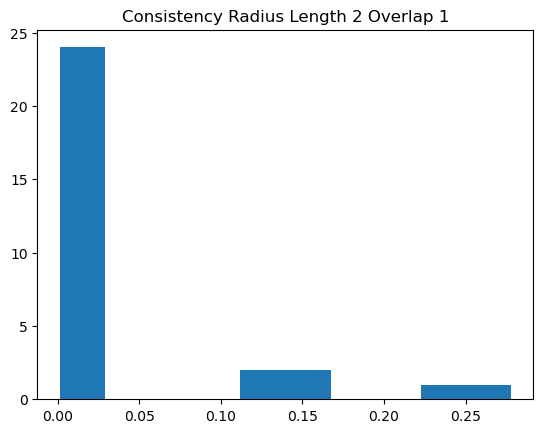

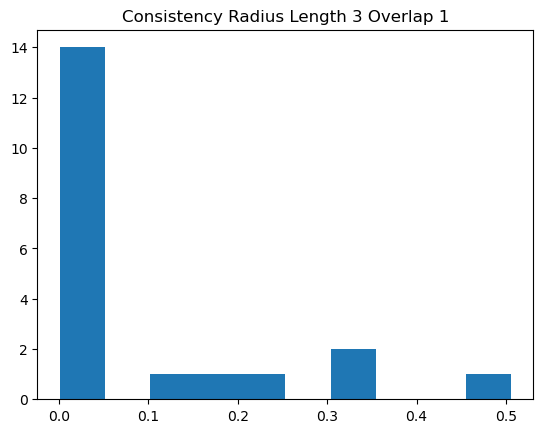

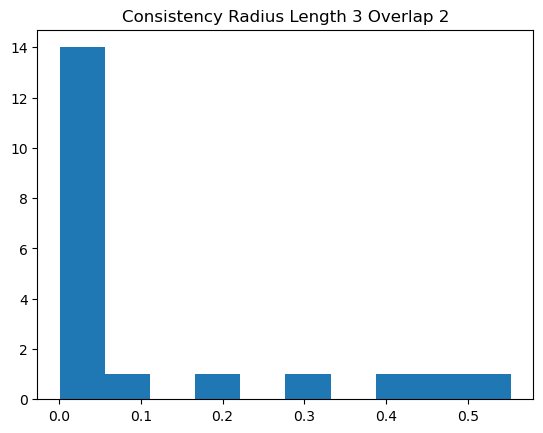

In [5]:

lengths = [2, 3]
CR_dict = {}

for l in lengths: 
    for o in list(range(1,12)):  
        if o == l:
            break
        else: 
            from enum import Enum
            
            class CellConstraintType(Enum):
                EQUALITY = 0
                INEQUALITY = 1
            
            ps.CellConstraintType = CellConstraintType
            
            consistency_radius = []
            
            overlap = o     # how many years the sheaf overlap 
            length = l     # how many years long is each sheaf 
            origin_year = 1959   # year data starts 
            final_year = 2019
            n_sheafs = int((final_year - origin_year) / length) # number of sheafs 
                
            for n in range(0, n_sheafs): 
                if n == 0:
                    startyear = origin_year 
                else: 
                    startyear = origin_year + (10 * n) + overlap
                
                endyear = startyear + length 
                npts = endyear - startyear + 1   # has to be endyear - startyear + 1 
                ar = 1
                shf = netlist_sheaf.NetlistSheaf(parts,nets,npts=npts,ar=ar,lag_fcn=lag_fcn)
                
                measurements = defaultdict(list)
                with open('/Users/trixiesouthwood/Downloads/research/log_isle_royal_data.csv') as fp:
                    reader = csv.DictReader(fp, delimiter = ',')
                    idx = 0
                    for row in reader:
                        for data_name,sheaf_name in names_dict.items():
                            if row[data_name] != 'NA':
                                year = origin_year + idx 
                                if year > endyear:
                                    break 
                                        
                            if year >= startyear: 
                                
                                    datum = str(year) + "-" + sheaf_name
                                    value = float(row[data_name])
                    
                                    measurements[sheaf_name].append((year,value))
                                    
                                    shf.AddCell(datum, ps.Cell('datum',dataDimension=1))
                                    shf.GetCell(datum).SetDataAssignment(ps.Assignment('datum', np.array([value])))
                                    shf.AddCoface(sheaf_name,datum,
                                                  ps.Coface('net','datum', lambda x,i  = year - startyear: x[i] ))
                            
                        idx = idx + 1
                
                # Load in DSEM predictions
                dsem_values = defaultdict(list)
                with open('/Users/trixiesouthwood/Downloads/research/wolf_moose_dsem.csv') as fp:   
                    reader = csv.DictReader(fp, delimiter = ',')
                    idx = 0
                    for row in reader:
                        for data_name,sheaf_name in names_dict.items():
                            if row[data_name] != 'NA':
                                year = origin_year + idx 
                                
                                if year > endyear:
                                    break 
                            
                                if year >= startyear: 
                
                                    datum = str(year) + "-" + sheaf_name
                                    value = float(row[data_name])
                    
                                    dsem_values[sheaf_name].append((year,value))        
                       
                        idx = idx + 1
            
            
                for c in shf.GetCellIndexList():
                    shf.MaximallyExtendCell(c)
                
    
                shf.FuseAssignment()
                
                consistency_radius.append(shf.ComputeConsistencyRadius())

               
                
                years=[startyear + year for year in range(npts)]

        key = f"length{l}_overlap{o}"
        
        CR_dict[key] = consistency_radius

    
        plt.hist(consistency_radius) 
        plt.title(f"Consistency Radius Length {l} Overlap {o}")
        plt.show()


